# Sensor and Sensing Technology Classification

This notebook classifies the screened walkability corpus by sensing modality (the
technology used as the measurement instrument), as a companion axis to the walkability
dimension classification (`06_2_Walkability_Dimension_Classification.ipynb`).

Design choice, and why it differs from both existing pipelines it draws on:

- Walkability dimensions (safety, comfort, etc.) are abstract constructs rarely named
  literally in text, so that notebook uses zero-shot NLI entailment, which is built for
  inferring meaning that is not stated verbatim.
- Sensor and technology names ("LiDAR", "accelerometer", "Street View", "GPS") are
  concrete technical terms that tend to appear near-literally in abstracts and
  introductions. For this kind of vocabulary, keyword-anchored semantic similarity
  (the approach used in João's GenAI-technology detection notebook) is a better fit
  than NLI: it does not force many candidate labels to compete for probability mass,
  which is what caused 75% of records to be left unassigned at a fixed 0.5 threshold
  in the dimension-classification run.
- That said, the GenAI notebook's threshold (0.4) was also picked without calibration,
  and its category aggregation is binary (keyword present or not), discarding
  confidence. This notebook keeps the keyword-similarity detection mechanism, but adds
  the calibration and hierarchical-aggregation rigor used in the dimension notebook:
  inspecting the score distribution before fixing a threshold, and aggregating each
  macro sensor category by its strongest matching keyword score rather than by mere
  presence/absence.

# Import Required Libraries

In [1]:
import json
import os
import re
import numpy as np
import pandas as pd
from collections import Counter
from tqdm import tqdm

import torch
from sentence_transformers import SentenceTransformer, util

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 100)
sns.set(style="whitegrid")
plt.rcParams.update({"font.size": 12})
plt.rcParams.update({"font.family": "Times New Roman"})

# Load and Prepare Data

Uses the same screened corpus as the dimension-classification notebook
(`05_filtered_walkability_applications.json`), not the dimension-filtered subset, so
that sensor type is extracted independently across the full screened corpus rather
than compounding the dimension notebook's threshold-driven record loss.

In [2]:
df = pd.read_json("../data/05_filtered_walkability_applications.json")
print(f"Total articles processed: {len(df)}")

Total articles processed: 968


# Define Sensor and Sensing Technology Taxonomy

Macro sensing-modality categories, each broken down into keyword phrases describing
how that modality is typically named in text.

In [3]:
with open("../data/config/sensor_technology_domains.json", "r", encoding="utf8") as f:
    sensor_technologies = json.load(f)

# Flatten to a keyword list with a lookup back to its macro category
keyword_to_macro = {}
for macro_category, keywords in sensor_technologies.items():
    for keyword in keywords:
        keyword_to_macro[keyword] = macro_category

keyword_list = list(keyword_to_macro.keys())
print(f"Total number of keyword phrases: {len(keyword_list)}")
print(f"Macro sensor categories: {list(sensor_technologies.keys())}")

Total number of keyword phrases: 45
Macro sensor categories: ['Street-View and Image-Based Sensing', 'Remote and Aerial Sensing', 'Wearable and Mobile Sensing', 'Environmental and IoT Sensing', 'Traffic and Infrastructure Sensing', 'Crowdsourced and Participatory Sensing', 'Acoustic Sensing']


> **Note:** `sensor_technology_domains.json` is a draft covering the sensing modalities
> commonly seen in walkability/sensor literature (street-view and image-based, remote and
> aerial, wearable and mobile, environmental/IoT, traffic and infrastructure, crowdsourced,
> acoustic). Review and extend the keyword lists per macro category against your own
> corpus before treating results as final — the rest of the pipeline does not need to
> change if only the config file is edited.

# Set Up Semantic Matching Environment

Uses `all-mpnet-base-v2`, the same embedding model already validated earlier in this
project's screening pipeline, rather than a smaller general-purpose model, for
consistency across notebooks.

In [4]:
DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print(f"Using device: {DEVICE}")

print("Loading sentence embedding model...")
sbert_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2", device=DEVICE)

print("Computing embeddings for sensor keyword phrases...")
keyword_embeddings = sbert_model.encode(keyword_list, convert_to_tensor=True)

Using device: cuda
Loading sentence embedding model...
Computing embeddings for sensor keyword phrases...


# Implement Detection Function

For each abstract, splits the introduction into sentence-level segments, embeds each
segment, and compares it against every keyword phrase. Unlike a binary keyword-match
flag, this keeps a continuous score per macro category (the strongest matching
keyword's similarity), so the threshold can be calibrated the same way as in the
dimension-classification notebook rather than fixed in advance.

In [5]:
def detect_sensor_technologies(text, top_k_per_segment=5):
    """
    Returns per-keyword similarity matches and per-macro-category aggregated scores
    (max similarity across that category's keywords) for one abstract's text.
    """
    empty_result = {
        "matched_keywords": [],
        "keyword_scores": {},
        "macro_scores": {cat: 0.0 for cat in sensor_technologies},
    }
    if text is None or not isinstance(text, str) or text.strip() == "":
        return empty_result

    sentences = re.split(r"[.!?]", text)
    sentences = [s.strip() for s in sentences if len(s.strip()) > 20]
    text_segments = sentences if len(sentences) > 3 else [text]

    keyword_scores = {}
    try:
        segment_embeddings = sbert_model.encode(text_segments, convert_to_tensor=True)
        similarities = util.pytorch_cos_sim(segment_embeddings, keyword_embeddings)
        # Take, for each keyword, the highest similarity across all segments of this text
        max_sim_per_keyword = similarities.max(dim=0).values

        for keyword_idx, keyword in enumerate(keyword_list):
            score = max_sim_per_keyword[keyword_idx].item()
            keyword_scores[keyword] = score
    except Exception as e:
        print(f"Error in semantic matching: {e}")
        return empty_result

    matched_keywords = sorted(keyword_scores.items(), key=lambda x: x[1], reverse=True)[:top_k_per_segment]

    macro_scores = {cat: 0.0 for cat in sensor_technologies}
    for keyword, score in keyword_scores.items():
        macro_category = keyword_to_macro[keyword]
        macro_scores[macro_category] = max(macro_scores[macro_category], score)

    return {
        "matched_keywords": matched_keywords,
        "keyword_scores": keyword_scores,
        "macro_scores": macro_scores,
    }

# Test with a Single Sentence

In [6]:
test_text = ("This study deploys accelerometer-equipped wearable devices and smartphone "
             "GPS sensors on volunteer pedestrians to record movement patterns across "
             "the city.")
test_result = detect_sensor_technologies(test_text)
print("Top matched keywords:")
for keyword, score in test_result["matched_keywords"]:
    print(f"  - {keyword}: {score:.4f}")
print("\nMacro category scores:")
for category, score in sorted(test_result["macro_scores"].items(), key=lambda x: x[1], reverse=True):
    print(f"  - {category}: {score:.4f}")

Top matched keywords:
  - mobile phone sensing: 0.5914
  - pedestrian counting sensor: 0.5588
  - participatory sensing platform: 0.4916
  - smartphone built-in sensor: 0.4864
  - accelerometer data: 0.4856

Macro category scores:
  - Wearable and Mobile Sensing: 0.5914
  - Traffic and Infrastructure Sensing: 0.5588
  - Crowdsourced and Participatory Sensing: 0.4916
  - Acoustic Sensing: 0.4183
  - Environmental and IoT Sensing: 0.3945
  - Street-View and Image-Based Sensing: 0.2918
  - Remote and Aerial Sensing: 0.1611


# Apply Detection to the Corpus

In [7]:
df_filtered = df[df["introduction"].str.strip().astype(bool)].copy()
print(f"Classifying introductions from {len(df_filtered)} abstracts...")

tqdm.pandas(desc="Detecting sensor technologies")
detection_results = df_filtered["introduction"].progress_apply(detect_sensor_technologies)

df_filtered["sensor_matched_keywords"] = detection_results.apply(lambda r: r["matched_keywords"])
df_filtered["sensor_macro_scores"] = detection_results.apply(lambda r: r["macro_scores"])

Classifying introductions from 968 abstracts...


Detecting sensor technologies: 100%|██████████| 968/968 [00:54<00:00, 17.81it/s]


In [8]:
# Display example classifications
print("\nExample classifications:")
for i, (_, row) in enumerate(df_filtered.sample(min(5, len(df_filtered))).iterrows()):
    print(f"\nAbstract {i+1} (DOI: {row['doi']}):")
    print(f"Introduction (truncated): {row['introduction'][:200]}...")
    print("Top 3 macro sensor categories:")
    top_macro = sorted(row["sensor_macro_scores"].items(), key=lambda x: x[1], reverse=True)[:3]
    for category, score in top_macro:
        print(f"  - {category}: {score:.4f}")


Example classifications:

Abstract 1 (DOI: 10.1016/j.ypmed.2018.10.024):
Introduction (truncated): Characteristics of the environment influence health and may promote physical activity. We explored the associations between neighborhood environmental characteristics grouped within five facets (space...
Top 3 macro sensor categories:
  - Wearable and Mobile Sensing: 0.4545
  - Environmental and IoT Sensing: 0.3652
  - Traffic and Infrastructure Sensing: 0.3153

Abstract 2 (DOI: 10.1007/s10708-021-10441-2):
Introduction (truncated): Walking behavior is influenced by both objective and subjective aspects of the built environment at the macro and micro scales. Most walkability studies focused on objective macro or mesoscale variabl...
Top 3 macro sensor categories:
  - Street-View and Image-Based Sensing: 0.4225
  - Acoustic Sensing: 0.3275
  - Crowdsourced and Participatory Sensing: 0.3103

Abstract 3 (DOI: 10.1016/j.ufug.2024.128291):
Introduction (truncated): Understanding the relations

# Evaluate Score Distribution to Determine the Threshold

The same calibration step that was skipped for both source notebooks this one draws
on — inspect the actual score distribution before fixing a threshold, instead of
picking a round number in advance.

Possible thresholds:
  - fixed_conservative: 0.5000
  - fixed_liberal: 0.4000
  - mean: 0.2846
  - median: 0.2764
  - percentile_75: 0.3586
  - percentile_90: 0.4403

Macro categories assigned per abstract with different thresholds:
  - fixed_conservative (threshold=0.5000): 0.34 categories per abstract
  - fixed_liberal (threshold=0.4000): 1.11 categories per abstract
  - mean (threshold=0.2846): 3.31 categories per abstract
  - median (threshold=0.2764): 3.50 categories per abstract
  - percentile_75 (threshold=0.3586): 1.75 categories per abstract
  - percentile_90 (threshold=0.4403): 0.70 categories per abstract


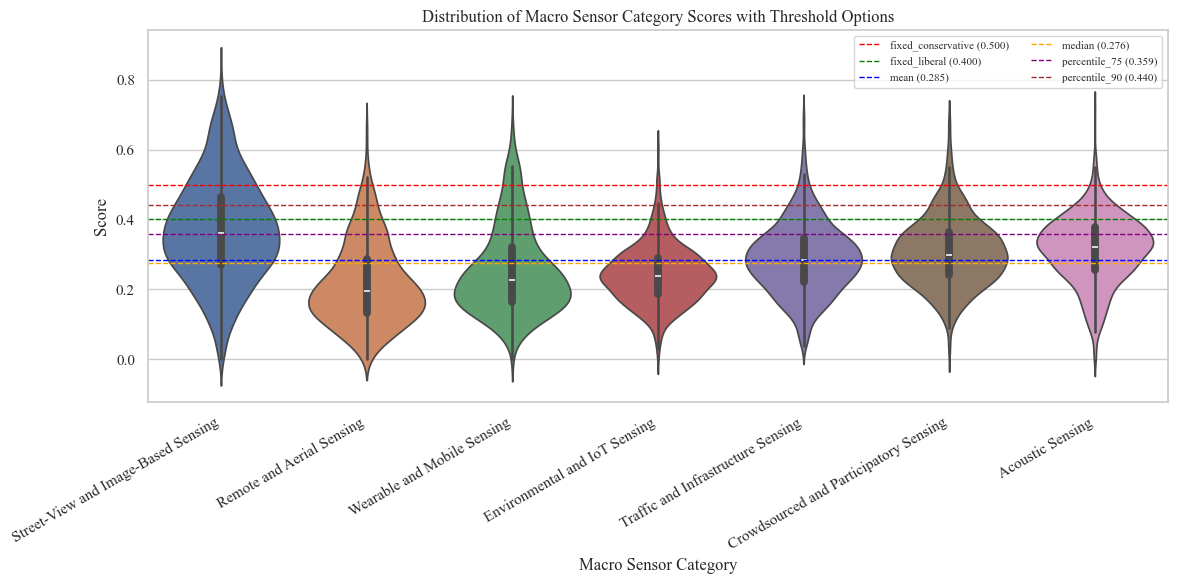

In [9]:
macro_scores_df = pd.DataFrame(list(df_filtered["sensor_macro_scores"]))

all_scores = macro_scores_df.values.flatten()
all_scores = all_scores[~np.isnan(all_scores)]

thresholds = {
    "fixed_conservative": 0.5,
    "fixed_liberal": 0.4,
    "mean": np.mean(all_scores),
    "median": np.median(all_scores),
    "percentile_75": np.percentile(all_scores, 75),
    "percentile_90": np.percentile(all_scores, 90),
}

print("Possible thresholds:")
for name, value in thresholds.items():
    print(f"  - {name}: {value:.4f}")

print("\nMacro categories assigned per abstract with different thresholds:")
for name, threshold in thresholds.items():
    categories_per_abstract = (macro_scores_df >= threshold).sum(axis=1)
    print(f"  - {name} (threshold={threshold:.4f}): {categories_per_abstract.mean():.2f} categories per abstract")

plt.figure(figsize=(12, 6))
sns.violinplot(data=macro_scores_df)
plt.xticks(rotation=30, ha="right")
plt.title("Distribution of Macro Sensor Category Scores with Threshold Options")
plt.ylabel("Score")
plt.xlabel("Macro Sensor Category")

colors = ["red", "green", "blue", "orange", "purple", "brown"]
for (name, threshold), color in zip(thresholds.items(), colors):
    plt.axhline(y=threshold, color=color, linestyle="--", linewidth=1, label=f"{name} ({threshold:.3f})")

plt.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

# Assign Macro Sensor Categories

Uses the mean-based threshold by default rather than a fixed round number, given the
dilution problem observed with a fixed 0.5 threshold on the dimension-classification
notebook. Review the plot above and adjust `CONFIG_SCORE_THRESHOLD` before treating
the assignment as final; validating it against a small manually coded sample (the same
principle already applied to the inclusion/exclusion screening step) is recommended
before reporting these counts.

In [10]:
CONFIG_SCORE_THRESHOLD = thresholds["mean"]

def assign_macro_sensor_categories(macro_scores, threshold):
    return [category for category, score in macro_scores.items() if score >= threshold]

df_filtered["macro_sensor_types"] = df_filtered["sensor_macro_scores"].apply(
    lambda scores: assign_macro_sensor_categories(scores, CONFIG_SCORE_THRESHOLD)
)

category_counts = Counter()
for categories in df_filtered["macro_sensor_types"]:
    category_counts.update(categories)

print(f"Threshold used: {CONFIG_SCORE_THRESHOLD:.4f}\n")
print("Sensor category distribution:")
for category, count in category_counts.most_common():
    print(f"  - {category}: {count} abstracts")

avg_categories = np.mean([len(c) for c in df_filtered["macro_sensor_types"]])
multi_category = sum(1 for c in df_filtered["macro_sensor_types"] if len(c) > 1)
print(f"\nAverage sensor categories per abstract: {avg_categories:.2f}")
print(f"Abstracts with multiple sensor categories: {multi_category} ({multi_category/len(df_filtered)*100:.2f}%)")

Threshold used: 0.2846

Sensor category distribution:
  - Street-View and Image-Based Sensing: 691 abstracts
  - Acoustic Sensing: 637 abstracts
  - Crowdsourced and Participatory Sensing: 561 abstracts
  - Traffic and Infrastructure Sensing: 486 abstracts
  - Wearable and Mobile Sensing: 310 abstracts
  - Environmental and IoT Sensing: 265 abstracts
  - Remote and Aerial Sensing: 252 abstracts

Average sensor categories per abstract: 3.31
Abstracts with multiple sensor categories: 738 (76.24%)


# Visualize Sensor Category Distribution

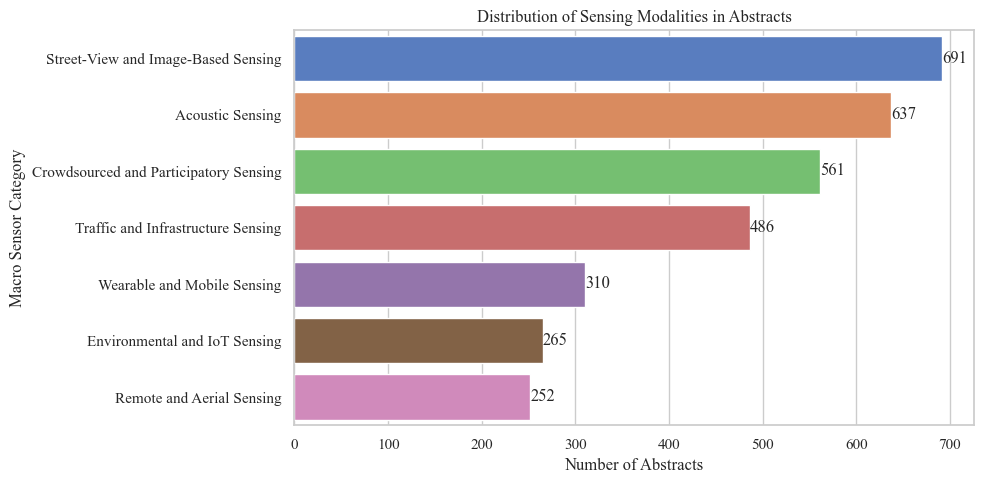

In [11]:
palette = sns.color_palette("muted", n_colors=len(category_counts))
categories_list = [category for category, count in category_counts.most_common()]
counts = [count for category, count in category_counts.most_common()]

plt.figure(figsize=(10, 5))
sns.barplot(x=counts, y=categories_list, hue=categories_list, palette=palette, legend=False)
plt.xlabel("Number of Abstracts")
plt.ylabel("Macro Sensor Category")
plt.title("Distribution of Sensing Modalities in Abstracts")

for i, count in enumerate(counts):
    plt.text(count + 0.2, i, str(count), va="center")

plt.tight_layout()
plt.show()

# Filter Articles with No Sensor Category Assigned

In [12]:
no_category_mask = df_filtered["macro_sensor_types"].apply(lambda x: len(x) == 0)
no_category_df = df_filtered[no_category_mask]

df_filtered = df_filtered[~no_category_mask].copy()
df_filtered = df_filtered.reset_index(drop=True)
print(f"Filtered DataFrame size: {len(df_filtered)} articles with an assigned sensor category")
print(f"Articles with no sensor category assigned: {len(no_category_df)}")

Filtered DataFrame size: 835 articles with an assigned sensor category
Articles with no sensor category assigned: 133


# Save the Results

Saves `macro_sensor_types` keyed by DOI, so it can be merged into the walkability
dimension output (`06_2_classified_walkability_dimensions.json`) for the sensor x
dimension crosstab already stubbed into that notebook.

In [13]:
df_filtered.to_json("../data/06_3_classified_sensor_types.json", orient="records", indent=4)
no_category_df.to_json("../data/06_3_1_no_assigned_sensor_types.json", orient="records", indent=4)

print(f"Saved:\n  ../data/06_3_classified_sensor_types.json ({len(df_filtered)} records)"
      f"\n  ../data/06_3_1_no_assigned_sensor_types.json ({len(no_category_df)} records)")

Saved:
  ../data/06_3_classified_sensor_types.json (835 records)
  ../data/06_3_1_no_assigned_sensor_types.json (133 records)


# Merge into the Dimension-Classified File (Optional)

Run this after both `06_2_Walkability_Dimension_Classification.ipynb` and this
notebook have produced their outputs, to populate the sensor x dimension crosstab
cell already present in the dimension notebook.

In [14]:
dimension_path = "../data/06_2_classified_walkability_dimensions.json"
if os.path.exists(dimension_path):
    df_dimensions = pd.read_json(dimension_path)
    merged = df_dimensions.merge(
        df_filtered[["doi", "macro_sensor_types"]], on="doi", how="left"
    )
    merged.to_json("../data/06_4_dimensions_with_sensor_types.json", orient="records", indent=4)
    print(f"Saved ../data/06_4_dimensions_with_sensor_types.json ({len(merged)} records) "
          f"-- re-run the crosstab cell in the dimension notebook against this file.")
else:
    print(f"{dimension_path} not found yet -- run the dimension-classification notebook first.")

Saved ../data/06_4_dimensions_with_sensor_types.json (244 records) -- re-run the crosstab cell in the dimension notebook against this file.
